In [83]:
using XLSX
using DataFrames
using CairoMakie
using Statistics
using Measurements
using LsqFit

In [ ]:
#Konstanten
fps = 32.792 #frames /s 
L = 0.96e-3 ± 0.01e-3 #in m und als Measurement
d = 2.50e-3 ± 0.03e-3  # Plattenabstand des Kondensators in m
η = 1.81e-5 ± 0.02e-5  #in Pa*s von Lut
g = 9.81                       #in m/s^2
ρ_öl = 1030                 #in kg/m^3 
ρ_luft = 1.29               #in kg/m^3
U = 459 ± 1                 #in V
Ac = 1.26
l_m = 6.4e-8                #in m l_mittelwert


6.4e-8

In [ ]:
#=
Wegen formationsproblemen in der Tabelle, Doppelte überschriften und leere Zellen, kommt es zu problemen im Code, daher muss 
das per hand erstellt werden. Das geschieht hier im Code, den ich on KI einfach genommen habe. Zugleiuch wird global das Minus 
weggenommen für positive Geschwindigkeiten, den das per exel zu machen hat nicht funktioniert, das gab komische sonderzeichen.
=#

# 1. Gesamtes Datenblatt als Matrix einlesen (
xf = XLSX.readxlsx("B1.3RohdatenMuster_voll.xlsx")
sh = xf["Rohdaten"]
mat = sh[:] # Das liest alle belegten Zellen des gesamten Blattes ein

# 2. Wir ignorieren die ersten beiden fehlerhaften Header-Zeilen
# Wir nehmen alle Daten ab Zeile 3 bis zum Ende
daten_matrix = mat[3:end, :]

# 3. In einen DataFrame umwandeln
df = DataFrame(daten_matrix, :auto)

# 4. Spaltennamen sauber vergeben
rename!(df, [
    "Tropfen", 
    "Spannung_Wert", 
    "Spannung_Fehler", 
    "Frames_Sinken_1", "Frames_Sinken_2", "Frames_Sinken_3", "Frames_Sinken_4", "Frames_Sinken_5",
    "Frames_Steigen_1", "Frames_Steigen_2", "Frames_Steigen_3", "Frames_Steigen_4", "Frames_Steigen_5"
])

# Falls du unten in der Excel aus Versehen leere Zellen hast, filtern wir diese raus:
dropmissing!(df, :Tropfen)

# 5. Fix: Die Frames in der Excel sind aus irgendeinem Grund negativ. 
# Wir wandeln alle Frame-Spalten in positive Werte (Betrag) um, damit die Zeit positiv wird.
for col in names(df)
    if occursin("Frames", col)
        df[!, col] = abs.(df[!, col])
    end
end

# Test
display(df)

#Die ganze Tabelle ist nun als df defeniert

Row,Tropfen,Spannung_Wert,Spannung_Fehler,Frames_Sinken_1,Frames_Sinken_2,Frames_Sinken_3,Frames_Sinken_4,Frames_Sinken_5,Frames_Steigen_1,Frames_Steigen_2,Frames_Steigen_3,Frames_Steigen_4,Frames_Steigen_5
,Any,Any,Any,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,1,459,1,148,125,128,131,130,188,177,176,180,177
2,2,459,1,123,117,117,112,119,148,146,150,147,145
3,3,459,1,98,97,96,93,93,111,108,108,109,107
4,4,459,1,106,105,105,104,103,126,128,126,127,125
5,5,459,1,114,113,109,112,111,135,133,135,139,135
6,6,459,1,145,146,144,146,145,248,253,243,251,264
7,7,459,1,78,76,79,79,76,97,95,99,97,97
8,8,459,1,100,101,105,103,102,123,123,121,126,119
9,9,459,1,50,53,51,51,51,56,56,55,55,53


In [ ]:
#Zeit für ein Tropfen berechen zum ausprobieren
#(Zeile, Spalte)

#Spalten 4 bis 8 sind sinken , diese Eintraäge als Vector ausgeben lassen
frames_sinken_t1 = Vector(df[1, 4:8])

#Spalten 9 bis 13 sidn steigen 
frames_steigen_t1 = Vector(df[1, 9:13])

#Jetzt diese durch fps teilen für Vector an Zeit
zeit_sinken_t1 = frames_sinken_t1 ./fps
zeit_steigen_t1 = frames_steigen_t1 ./fps

#Mittelwert und Standartabweichung berechnen
t_sinken_1 = mean(zeit_sinken_t1)
Δt_sinken_1 = std(zeit_sinken_t1) /√5

t_steigen_1 = mean(zeit_steigen_t1)
Δt_steigen_1 = std(zeit_steigen_t1)/√5


#Geschw. berechn - Strecke durch Zeit teilen



0.00012296807241800407

In [54]:
#Schleife für alle 20 Tropfen zur v-Berechnung

#Leere DataFrames anlegen zum Speichern
#Measurement kombiniert wert und Fehler und berechnet dann zukünftig automatisch die Fehlerfortpflanzung
#so müssen die Fehler mittels dieser Art nicht per Hand ausgerechnet werden. Das geschieht alles automatisch
df.t_sinken = zeros(Measurement{Float64}, 20)
df.t_steigen = zeros(Measurement{Float64}, 20)



for i in 1:20
    t_sinken_i = mean( Vector(df[i, 4:8]) ./fps)
    Δt_sinken_i = std(Vector(df[i, 4:8]) ./fps) /√5

    t_steigen_i = mean( Vector(df[i, 9:13]) ./fps)
    Δt_steigen_i = std(Vector(df[i, 9:13]) ./fps) /√5

    df.t_sinken[i] = t_sinken_i ± Δt_sinken_i
    df.t_steigen[i] = t_steigen_i ± Δt_steigen_i

end

#Zeit = df[:, ["Tropfen", "t_sinken", "t_steigen"]]; # t_sinken und t_steigen als eine DataFrame
t_sinken = df.t_sinken
t_steigen = df.t_steigen


#Geschwindigkeiten berechnen
v_sinken = L ./ t_sinken
v_steigen = L ./t_steigen;


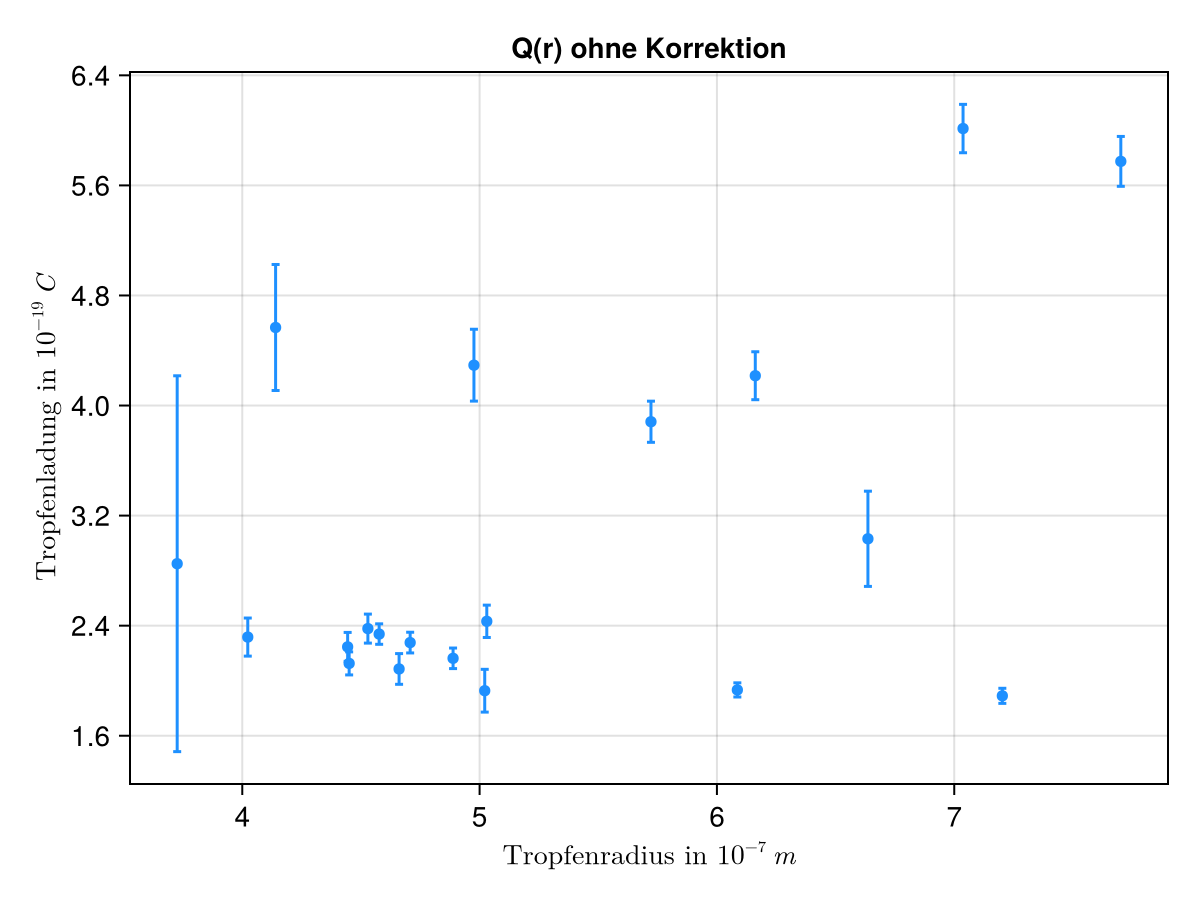

In [76]:
#Q und r ohne Korrektur berechnen
r =  sqrt.( (9*η .*(v_sinken .- v_steigen)) ./ (4*g*(ρ_öl - ρ_luft))  )

Q = (9*π*d)/(2*U) .* sqrt.(  (η^3 .*(v_sinken .- v_steigen)) ./ (g*(ρ_öl-ρ_luft)) ) .* (v_sinken .+ v_steigen)

r_skaliert = r ./1e-7
Q_skaliert = Q ./1e-19

r_val = Measurements.value.(r_skaliert)
r_err = Measurements.uncertainty.(r_skaliert)

Q_val = Measurements.value.(Q_skaliert)
Q_err = Measurements.uncertainty.(Q_skaliert)


fig = Figure()
ax = Axis(fig[1,1], xlabel = L"\text{Tropfenradius in } 10^{-7}\: m", ylabel =L"\text{Tropfenladung in }10^{-19}\: C", 
title ="Q(r) ohne Korrektion", yticks=LinearTicks(8))

errorbars!(ax, r_val, Q_val, Q_err, color=:dodgerblue, whiskerwidth=4)
scatter!(ax, r_val, Q_val, markersize=8, color=:dodgerblue)
fig

#=
Die erwartete Treppenverteilung ist ohne Korrektion nicht zu finden, und wie in der NAleitung vorhergesagt,
steigt die ladung mit klein r. Dennoch sind drei hauptbereiche der Ladungsverteilung zu erkennen.
Der immer noch zu hohe Wert bei klein r, ≈ 2C entsteht da Reibung berechneet wird, die nicht da ist.
=#

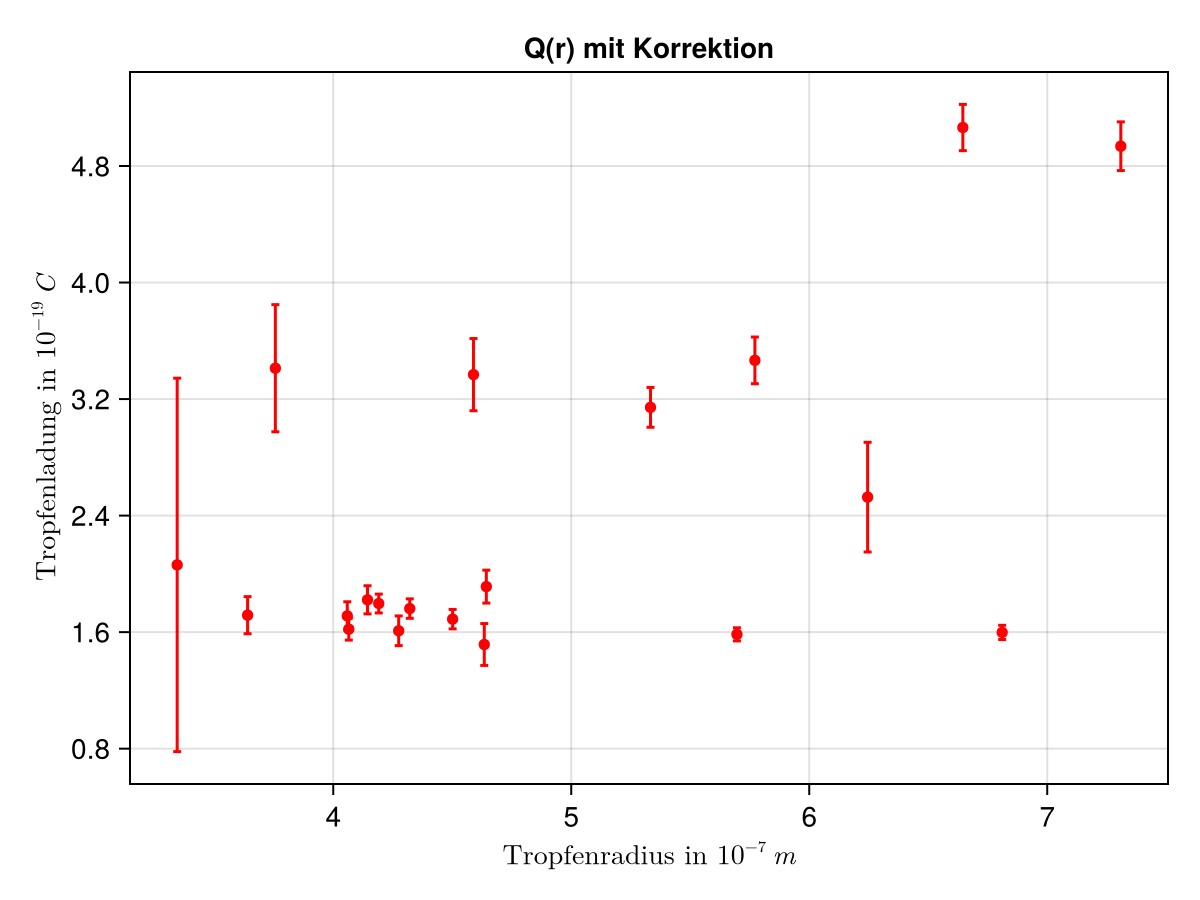

In [77]:
#Mit Korrektion
r_K = (-Ac*l_m)/2 .+ sqrt.(  ((Ac*l_m)/2)^2 .+ (9*η .*(v_sinken .-v_steigen)) ./(4*g*(ρ_öl-ρ_luft))  )
Q_K = (3*π*η*d)/U .* r_K .* (1 .+ Ac.*l_m ./ r_K).^(-1) .* (v_steigen .+ v_sinken)

r_K_skaliert = r_K ./1e-7
Q_K_skaliert = Q_K ./1e-19

#Fehler hinzufügen
r_K_val = Measurements.value.(r_K_skaliert)
r_K_err = Measurements.uncertainty.(r_K_skaliert)

Q_K_val = Measurements.value.(Q_K_skaliert)
Q_K_err = Measurements.uncertainty.(Q_K_skaliert)

fig2 = Figure()
ax = Axis(fig2[1,1], xlabel = L"\text{Tropfenradius in } 10^{-7}\: m", ylabel =L"\text{Tropfenladung in }10^{-19}\: C", 
title ="Q(r) mit Korrektion", yticks = LinearTicks(8))

#Fehler r
#errorbars!(ax, r_val, Q_val, r_err, direction=:x, color=:gray, whiskerwidth=4)

#Fehler Q
errorbars!(ax, r_K_val, Q_K_val, Q_K_err, color=:red, whiskerwidth=4)

scatter!(ax, r_K_val, Q_K_val, markersize=8, color=:red)
fig2

#=
Die Stufen sind deutlich besser zu erkennen. Die Fehler von r wurden wegen lesbarkei weggelassen.
Die Fehler steigen mit kleiner r, was physikalisch sinnvoll ist. Je kleiner, desto stärker hat Brownse bewegung
Einfluss auf die Teilchen und die exakte Geschwindigkeit zu messen wird schwiriger. 
=#

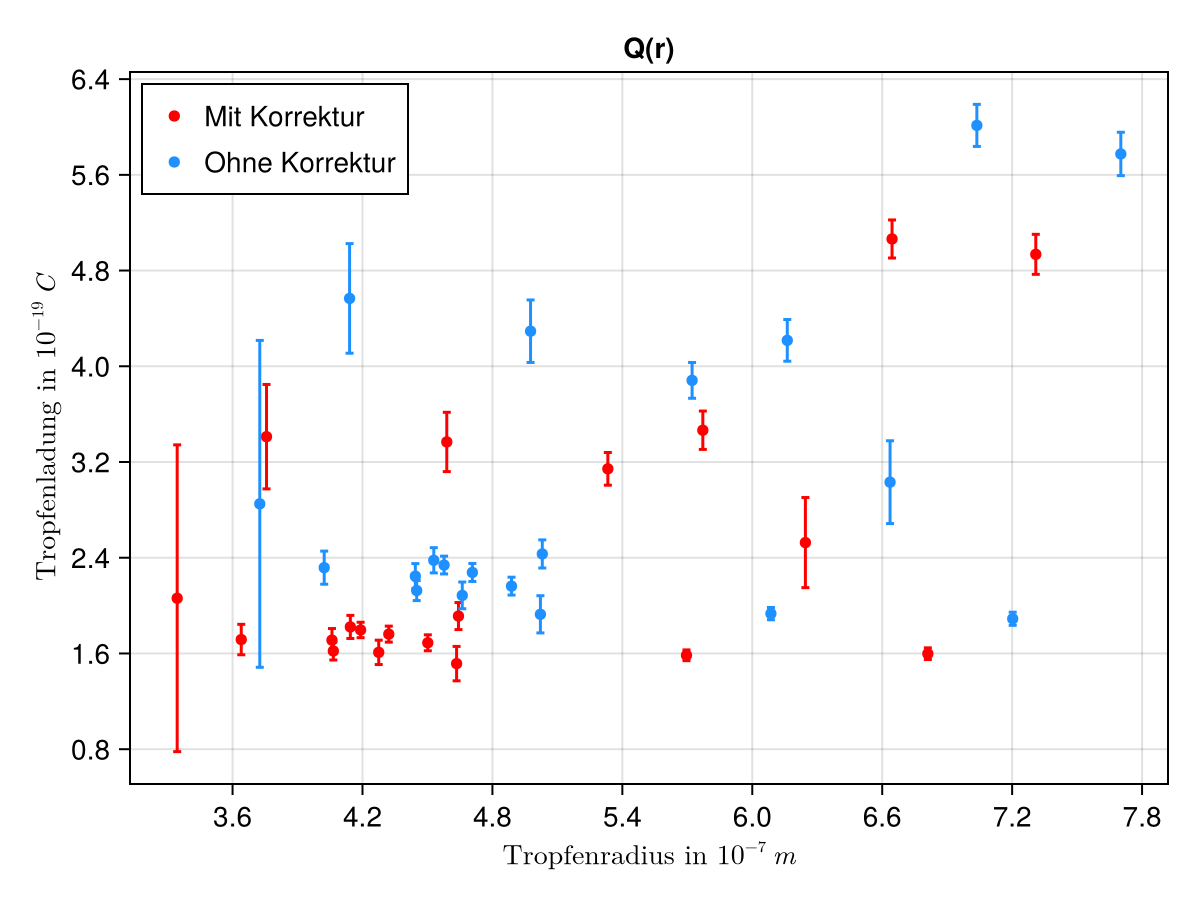

In [81]:
fig3=Figure()
ax=Axis(fig3[1,1], xlabel=L"\text{Tropfenradius in }10^{-7}\:m ", ylabel=L"\text{Tropfenladung in }10^{-19}\:C",
title ="Q(r)", yticks=LinearTicks(8), xticks=LinearTicks(8))

errorbars!(ax, r_K_val, Q_K_val, Q_K_err, color=:red, whiskerwidth=4)
scatter!(ax, r_K_val, Q_K_val, markersize=8, color=:red, label="Mit Korrektur")

errorbars!(ax, r_val, Q_val, Q_err, color=:dodgerblue, whiskerwidth=4)
scatter!(ax, r_val, Q_val, markersize=8, color=:dodgerblue, label="Ohne Korrektur")

axislegend(ax, position=:lt)
fig3

In [82]:
save("Q_von_r_ohne_Korrektur.pdf",fig)
save("Q_von_r_mit_Korrektur.pdf",fig2)
save("Q_von_r_ueberlagert.pdf",fig3)

CairoMakie.Screen{PDF}


Steigung m = (1.643 ± 0.05)*10^{-19} C
y-Abschnitt b =0.027 ± 0.06


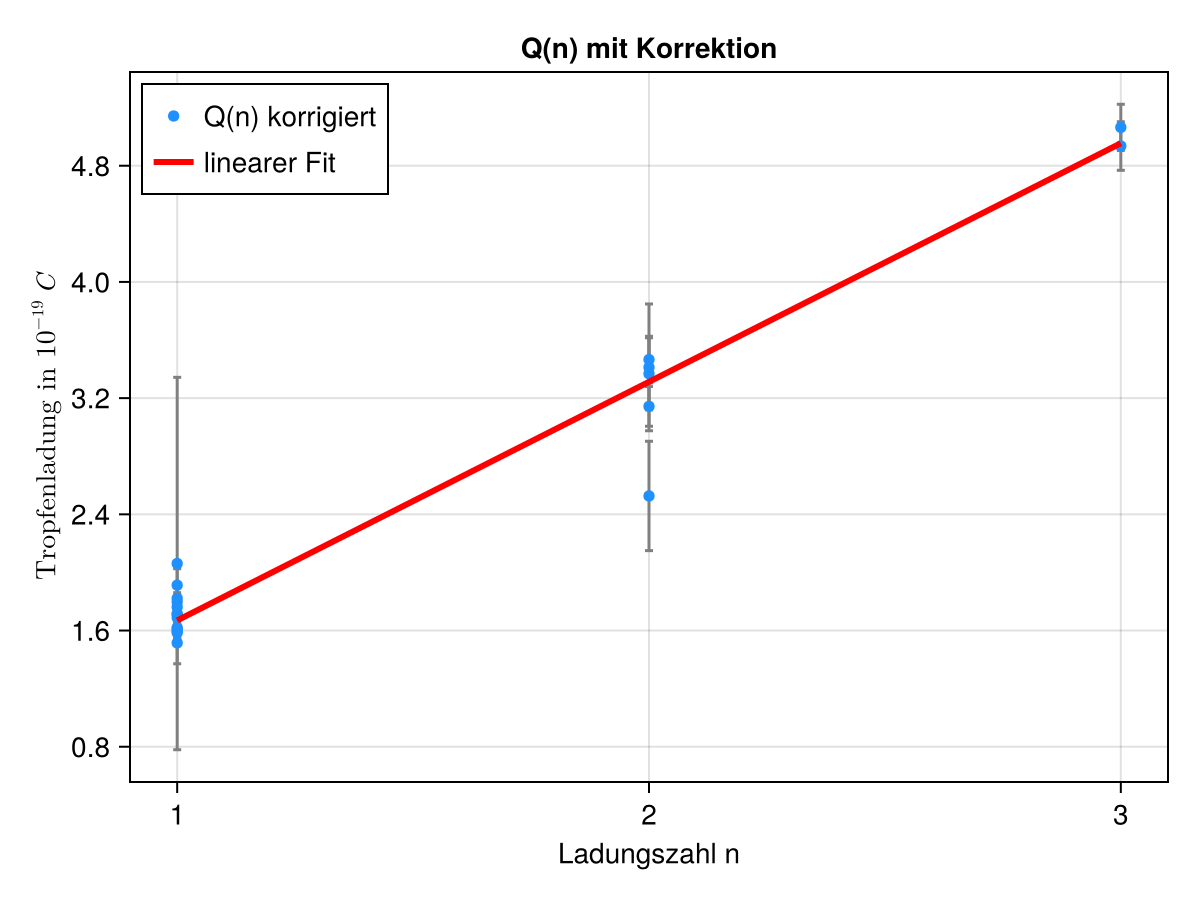

In [103]:
#Elementarladung durch lin.Fit bestimmen
#=
Es wird Q=e*n aufgetragen um dann mit lin.Fit e zu bestimmen. Um Q(n) zu erhalten wird der bereits bekannte Literaturwert 
benutzt um n durch n=Q/e_lit zu bestimmen. 
Historisch wurde dies gemacht in dem die Tropfen mit Röntgenstrahlen bestreut und Ionisiert wurden.
Nach Ionisierung hat sich v geändert da Q sich änderte. Aus diesen Änderungen konnte durch Vergleich e bestimmt werden.
Wenn e_lit nur verwendet wird um n zu bestimmen und dann die Steigung zu bestimmen ist das hoffentlich kein zirkelschluss.
Ich weiß nicht wie ich das sonst macehn soll.
=#



n = round.(Int, Q_K_skaliert ./1.602)

# 1. Daten für den Fit vorbereiten, LsqFit braucht  Floats, keine Measurement oder Int
n_val = Float64.(n)
Q_val = Measurements.value.(Q_K_skaliert)
Q_err = Measurements.uncertainty.(Q_K_skaliert)
gewichte = 1.0 ./ (Q_err .^ 2) # Kleinere Fehler bekommen mehr Gewicht beim Fitten

@. gerade(x, p) = p[1] * x + p[2]
p0 = [1.602, 0.0]

# Gewichte dem fit übergeben mit anfangswerten
fit = curve_fit(gerade, n_val, Q_val, gewichte, p0)

e, b = fit.param
Δe, Δb = stderror(fit)
println("Steigung m = ($(round(e, digits=3)) ± $(round(Δe, digits=3)))*10^{-19} C")
println("y-Abschnitt b =$(round(b, digits=3)) ± $(round(Δb, digits=3))")


fig4 = Figure()
ax = Axis(fig4[1, 1], 
    title = "Q(n) mit Korrektion", 
    xlabel = "Ladungszahl n", 
    ylabel = L"\text{Tropfenladung in }10^{-19}\: C",
    yticks = LinearTicks(8),
    xticks = minimum(n_val):1:maximum(n_val)) # gege intervall in ganzen stritten für x achse an


errorbars!(ax, n_val, Q_val, Q_err, color = :gray, whiskerwidth = 4)
scatter!(ax, n_val, Q_val, label = "Q(n) korrigiert", markersize = 8, color = :dodgerblue)

# 4. Fit-Linie berechnen, braucht zwei zahlen von wo, bis 
n_fit = range(minimum(n_val), maximum(n_val), length = 100)
Q_K_fit = gerade(n_fit, fit.param)

lines!(ax, n_fit, Q_K_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)
fig4

In [ ]:
#Relative Abweichung von etwas 2.5%


save("Q_von_n_Fit.pdf",fig4)

CairoMakie.Screen{PDF}
